# Classificação ninária

# Criando o dataset

Biblioteca TA-Lib encontrada.

--- ETAPA 1: CARREGANDO E JUNTANDO DADOS DE ÍNDICE E DÓLAR ---
Dados de Índice e Dólar carregados e juntados. Total de candles sincronizados: 98894

--- ETAPA 2: CALCULANDO FEATURES DE CONTEXTO DIÁRIO ---
Features de contexto diário completas calculadas.

--- ETAPA 3: GERANDO LABELS BINÁRIOS (0 ou 1) ---
Distribuição dos Label Binários:
label_binario
0    90
1    86
Name: count, dtype: int64


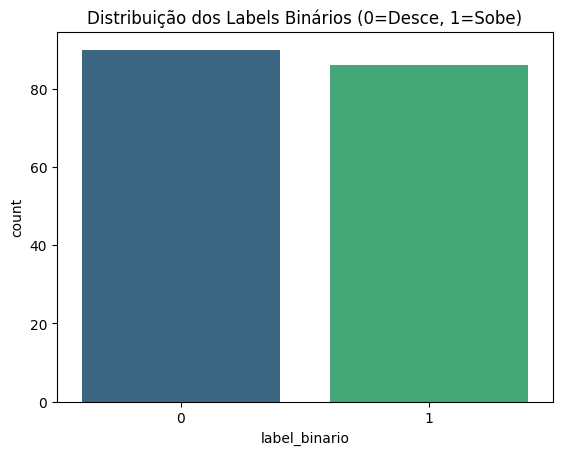


--- ETAPA 4: CALCULANDO TODAS AS FEATURES SEQUENCIAIS ---
Todas as features sequenciais foram calculadas.

--- ETAPA 5: ACHATANDO DADOS NA ORDEM HÍBRIDA ---
Achatamento e reordenação para o formato híbrido concluídos.

--- ETAPA 6: CRIANDO FEATURES CÍCLICAS E JUNTANDO TUDO ---
Junção final de todos os blocos de features e o novo label binário concluída.

--- ETAPA 7: SALVANDO E EXIBINDO O RESULTADO ---
Arquivo salvo como: 'dataset_binario.csv'
Dimensões do DataFrame final (dias, colunas): (94, 5050)
Total de dias válidos no dataset final: 94

Amostra do dataset final (início das colunas de contexto e início das sequenciais):


,range_dia_anterior,posicao_range_d1,distancia_mm20,mes_sin,mes_cos,dia_mes_sin,dia_mes_cos,dia_semana_sin,dia_semana_cos,mov_direcional_c1,...,ratio_vol_WIN_WDO_c412,ratio_vol_WIN_WDO_c413,ratio_vol_WIN_WDO_c414,ratio_vol_WIN_WDO_c415,ratio_vol_WIN_WDO_c416,ratio_vol_WIN_WDO_c417,ratio_vol_WIN_WDO_c418,ratio_vol_WIN_WDO_c419,ratio_vol_WIN_WDO_c420,label_binario
2025-07-09,0.009635,0.549451,0.009361,-0.5,-0.866025,0.968077,-0.250653,0.974928,-0.222521,-1,...,10.862241,2.397361,1.941329,1.962974,1.677663,2.263465,3.282804,4.658816,8.777822,0
2025-07-11,0.015438,0.634434,-0.014073,-0.5,-0.866025,0.790776,-0.612106,-0.433884,-0.900969,-1,...,19.308989,5.964479,6.024943,25.383459,17.740145,17.950682,10.550162,13.047074,10.423021,0
2025-07-14,0.009051,0.292000,-0.019089,-0.5,-0.866025,0.299363,-0.954139,0.000000,1.000000,1,...,5.507124,5.625786,1.867135,2.280719,4.365739,4.891710,11.529560,4.060396,3.737126,1
2025-07-16,0.013771,0.525199,-0.023074,-0.5,-0.866025,-0.101168,-0.994869,0.974928,-0.222521,-1,...,1.978416,2.101990,5.177885,14.831213,5.478025,11.682137,4.782482,3.812423,4.344828,1
2025-07-17,0.012844,0.390313,-0.025296,-0.5,-0.866025,-0.299363,-0.954139,0.433884,-0.900969,1,...,9.179775,2.425168,5.885880,4.223855,6.647790,4.225857,6.440623,15.615778,16.146853,0


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tenta usar a biblioteca TA-Lib se estiver instalada
try:
    import talib
    TALIB_INSTALLED = True
    print("Biblioteca TA-Lib encontrada.")
except ImportError:
    TALIB_INSTALLED = False
    print("Biblioteca TA-Lib não encontrada. Usando implementações alternativas.")

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_INDICE = 'WIN$N_M1_BRUTO.csv'
NOME_ARQUIVO_DOLAR = 'WDO$N_M1_BRUTO.csv'
NOME_ARQUIVO_SAIDA_FINAL = 'dataset_binario.csv' 

abertura_features = '9:00'
fechamento_features = '15:59'
abertura_labels = '16:00'
fechamento_labels = '16:59'
quantidade_velas = 420

# --- ETAPA 1: CARREGAMENTO E JUNÇÃO DOS DADOS BRUTOS ---
print("\n--- ETAPA 1: CARREGANDO E JUNTANDO DADOS DE ÍNDICE E DÓLAR ---")
def carregar_e_preparar_ativo(nome_arquivo, sufixo=''):
    df = pd.read_csv(nome_arquivo, sep=';', parse_dates=['datetime'], index_col='datetime')
    colunas_numericas = ['Abertura', 'Maxima', 'Minima', 'Fechamento', 'Volume_Real', 'Volume_Tick']
    for col in colunas_numericas:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(subset=colunas_numericas, inplace=True)
    if sufixo:
        df = df.add_suffix(sufixo)
    return df

try:
    df_indice = carregar_e_preparar_ativo(NOME_ARQUIVO_INDICE)
    df_dolar = carregar_e_preparar_ativo(NOME_ARQUIVO_DOLAR, sufixo='_dolar')
    df_completo = df_indice.join(df_dolar, how='inner')
    print(f"Dados de Índice e Dólar carregados e juntados. Total de candles sincronizados: {len(df_completo)}")
except Exception as e:
    print(f"ERRO na ETAPA 1: {e}")
    exit()

# --- ETAPA 2: CÁLCULO DAS FEATURES DE CONTEXTO DIÁRIO  ---
print("\n--- ETAPA 2: CALCULANDO FEATURES DE CONTEXTO DIÁRIO ---")
def calcular_contexto_diario_completo(df, sufixo=''):
    cols = {
        'Abertura': f'Abertura{sufixo}', 'Maxima': f'Maxima{sufixo}',
        'Minima': f'Minima{sufixo}', 'Fechamento': f'Fechamento{sufixo}'
    }
    df_diario = df.resample('D').agg(
       Abertura=(cols['Abertura'], 'first'), Maxima=(cols['Maxima'], 'max'),
       Minima=(cols['Minima'], 'min'), Fechamento=(cols['Fechamento'], 'last')
    ).dropna()
    
    if sufixo:
        df_diario = df_diario.rename(columns={k: f"{k}{sufixo}" for k in ['Abertura', 'Maxima', 'Minima', 'Fechamento']})

    # ATR
    high_low = df_diario[f'Maxima{sufixo}'] - df_diario[f'Minima{sufixo}']
    high_close = np.abs(df_diario[f'Maxima{sufixo}'] - df_diario[f'Fechamento{sufixo}'].shift(1))
    low_close = np.abs(df_diario[f'Minima{sufixo}'] - df_diario[f'Fechamento{sufixo}'].shift(1))
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df_diario[f'atr_dia_anterior{sufixo}'] = true_range.rolling(window=14, min_periods=1).mean().shift(1)
    
    # Outras features de contexto
    df_diario[f'range_dia_anterior{sufixo}'] = (df_diario[f'Maxima{sufixo}'].shift(1) - df_diario[f'Minima{sufixo}'].shift(1)) / df_diario[f'Abertura{sufixo}'].shift(1)
    df_diario[f'mm20_diaria{sufixo}'] = df_diario[f'Fechamento{sufixo}'].rolling(window=20).mean()
    df_diario[f'gap{sufixo}'] = (df_diario[f'Abertura{sufixo}'] - df_diario[f'Fechamento{sufixo}'].shift(1)) / df_diario[f'Fechamento{sufixo}'].shift(1)
    df_diario[f'posicao_range_d1{sufixo}'] = (df_diario[f'Abertura{sufixo}'] - df_diario[f'Minima{sufixo}'].shift(1)) / (df_diario[f'Maxima{sufixo}'].shift(1) - df_diario[f'Minima{sufixo}'].shift(1))
    df_diario[f'distancia_mm20{sufixo}'] = (df_diario[f'Abertura{sufixo}'] - df_diario[f'mm20_diaria{sufixo}'].shift(1)) / df_diario[f'mm20_diaria{sufixo}'].shift(1)
    
    df_diario.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df_diario

df_contexto_win = calcular_contexto_diario_completo(df_completo)
df_contexto_dolar = calcular_contexto_diario_completo(df_completo, sufixo='_dolar')
df_contexto_geral = df_contexto_win.join(df_contexto_dolar, how='inner')

'''
features_contexto_diarias = [
    'gap', 'range_dia_anterior', 'atr_dia_anterior', 'posicao_range_d1', 'distancia_mm20',
    'gap_dolar', 'range_dia_anterior_dolar', 'atr_dia_anterior_dolar', 'posicao_range_d1_dolar', 'distancia_mm20_dolar'
]
'''
features_contexto_diarias = [
    'range_dia_anterior', 'posicao_range_d1', 'distancia_mm20'
]
df_contexto_geral.dropna(subset=features_contexto_diarias, inplace=True)
print("Features de contexto diário completas calculadas.")

# ==============================================================================
# --- ETAPA 3: GERAÇÃO DE LABELS (LÓGICA ATUALIZADA PARA CLASSIFICAÇÃO BINÁRIA) ---
# ==============================================================================
print("\n--- ETAPA 3: GERANDO LABELS BINÁRIOS (0 ou 1) ---")
# 1. Agrega os dados da janela de tempo do alvo para cada dia.
df_janela_alvo = df_completo.between_time(abertura_labels, fechamento_labels)
daily_agg_features = df_janela_alvo.resample('D').agg(
    Abertura_11h=('Abertura', 'first'), Fechamento_11h55=('Fechamento', 'last')
).dropna()

# 2. Calcula o retorno total no período.
daily_agg_features['retorno_total'] = daily_agg_features['Fechamento_11h55'] - daily_agg_features['Abertura_11h']

# 3. Cria o label binário usando np.where.
#    - Se retorno_total >= 0, o preço subiu ou ficou estável -> label = 1 (Sobe)
#    - Se retorno_total < 0, o preço desceu -> label = 0 (Desce)
daily_agg_features['label_binario'] = np.where(daily_agg_features['retorno_total'] >= 0, 1, 0)

print("Distribuição dos Label Binários:")
print(daily_agg_features['label_binario'].value_counts())
sns.countplot(data=daily_agg_features, x='label_binario', palette='viridis', hue='label_binario', legend=False).set_title('Distribuição dos Labels Binários (0=Desce, 1=Sobe)')
plt.show()

# --- ETAPA 4: CÁLCULO DAS FEATURES SEQUENCIAIS (COMPLETO) ---
print("\n--- ETAPA 4: CALCULANDO TODAS AS FEATURES SEQUENCIAIS ---")
df_completo.replace(0, 1e-9, inplace=True)
for suffix in ['', '_dolar']:
    df_completo[f'mag_decisao{suffix}'] = abs(df_completo[f'Fechamento{suffix}'] - df_completo[f'Abertura{suffix}']) / df_completo[f'Abertura{suffix}']
    df_completo[f'mov_direcional{suffix}'] = np.sign(df_completo[f'Fechamento{suffix}'] - df_completo[f'Abertura{suffix}'])
    df_completo[f'pavio_superior{suffix}'] = (df_completo[f'Maxima{suffix}'] - df_completo[[f'Abertura{suffix}', f'Fechamento{suffix}']].max(axis=1)) / df_completo[f'Abertura{suffix}']
    df_completo[f'pavio_inferior{suffix}'] = (df_completo[[f'Abertura{suffix}', f'Fechamento{suffix}']].min(axis=1) - df_completo[f'Minima{suffix}']) / df_completo[f'Abertura{suffix}']
    df_completo[f'range_candle{suffix}'] = (df_completo[f'Maxima{suffix}'] - df_completo[f'Minima{suffix}']) / df_completo[f'Abertura{suffix}']
    df_completo[f'volume_real_norm{suffix}'] = df_completo[f'Volume_Real{suffix}'] / df_completo[f'Volume_Real{suffix}'].rolling(window=50, min_periods=1).mean()
    df_completo[f'volume_tick_norm{suffix}'] = df_completo[f'Volume_Tick{suffix}'] / df_completo[f'Volume_Tick{suffix}'].rolling(window=50, min_periods=1).mean()
    df_completo[f'tamanho_medio_ordem{suffix}'] = df_completo[f'Volume_Real{suffix}'] / df_completo[f'Volume_Tick{suffix}']
    ma_3 = df_completo[f'Fechamento{suffix}'].rolling(window=3).mean()
    ma_9 = df_completo[f'Fechamento{suffix}'].rolling(window=9).mean()
    df_completo[f'diferenca_MA{suffix}'] = (ma_3 - ma_9) / df_completo[f'Fechamento{suffix}']
    if TALIB_INSTALLED:
        df_completo[f'RSI{suffix}'] = talib.RSI(df_completo[f'Fechamento{suffix}'], timeperiod=14)
        macd, macdsignal, _ = talib.MACD(df_completo[f'Fechamento{suffix}'], fastperiod=12, slowperiod=26, signalperiod=9)
        df_completo[f'MACD{suffix}'] = macd - macdsignal
    else:
        delta = df_completo[f'Fechamento{suffix}'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        df_completo[f'RSI{suffix}'] = 100 - (100 / (1 + rs))
        ema_fast = df_completo[f'Fechamento{suffix}'].ewm(span=12, adjust=False).mean()
        ema_slow = df_completo[f'Fechamento{suffix}'].ewm(span=26, adjust=False).mean()
        macd_line = ema_fast - ema_slow
        signal_line = macd_line.ewm(span=9, adjust=False).mean()
        df_completo[f'MACD{suffix}'] = macd_line - signal_line
df_completo['correlacao_movel_WIN_WDO'] = df_completo['Fechamento'].rolling(window=24, min_periods=10).corr(df_completo['Fechamento_dolar'])
df_completo['ratio_vol_WIN_WDO'] = df_completo['Volume_Real'] / df_completo['Volume_Real_dolar']
df_completo.dropna(inplace=True)
print("Todas as features sequenciais foram calculadas.")

# --- ETAPA 5: ACHATAMENTO E REORDENAÇÃO HÍBRIDA ---
print("\n--- ETAPA 5: ACHATANDO DADOS NA ORDEM HÍBRIDA ---")
'''
features_sequenciais_nomes = [
    'mag_decisao', 'mov_direcional', 'pavio_superior', 'pavio_inferior', 'range_candle',
    'volume_real_norm', 'volume_tick_norm', 'tamanho_medio_ordem', 'diferenca_MA', 'RSI', 'MACD',
    'mag_decisao_dolar', 'mov_direcional_dolar', 'pavio_superior_dolar', 'pavio_inferior_dolar', 'range_candle_dolar',
    'volume_real_norm_dolar', 'volume_tick_norm_dolar', 'tamanho_medio_ordem_dolar', 'diferenca_MA_dolar', 'RSI_dolar', 'MACD_dolar',
    'correlacao_movel_WIN_WDO', 'ratio_vol_WIN_WDO'
]
'''
features_sequenciais_nomes = [
    'mov_direcional', 'pavio_superior', 'pavio_inferior', 'range_candle', 'tamanho_medio_ordem',
    'pavio_superior_dolar', 'pavio_inferior_dolar', 'range_candle_dolar',
    'volume_real_norm_dolar', 'tamanho_medio_ordem_dolar', 'correlacao_movel_WIN_WDO', 'ratio_vol_WIN_WDO'
]


df_janela_entrada = df_completo.between_time(abertura_features, fechamento_features).copy()
dias_com_24_candles = df_janela_entrada.index.normalize().value_counts()
dias_validos_counts = dias_com_24_candles[dias_com_24_candles == quantidade_velas].index
dias_finais = sorted(list(set(dias_validos_counts) & set(df_contexto_geral.index) & set(daily_agg_features.index)))
df_janela_filtrada = df_janela_entrada[df_janela_entrada.index.normalize().isin(dias_finais)]
grouped_by_day = df_janela_filtrada.groupby(df_janela_filtrada.index.normalize())
colunas_hibridas = [f'{feature}_c{i}' for feature in features_sequenciais_nomes for i in range(1, quantidade_velas+1)]
lista_dfs_achatados = []
dias_ordenados = sorted(grouped_by_day.groups.keys())
for feature in features_sequenciais_nomes:
    dados_feature = [group[feature].values for day, group in grouped_by_day]
    df_feature_achatada = pd.DataFrame(dados_feature, index=dias_ordenados)
    lista_dfs_achatados.append(df_feature_achatada)
df_features_sequenciais = pd.concat(lista_dfs_achatados, axis=1)
df_features_sequenciais.columns = colunas_hibridas
print("Achatamento e reordenação para o formato híbrido concluídos.")

# --- ETAPA 6: FEATURES CÍCLICAS (COMPLETO) E JUNÇÃO FINAL ---
print("\n--- ETAPA 6: CRIANDO FEATURES CÍCLICAS E JUNTANDO TUDO ---")
df_tempo = pd.DataFrame(index=pd.to_datetime(dias_finais))
df_tempo['mes_sin'] = np.sin(2 * np.pi * df_tempo.index.month / 12)
df_tempo['mes_cos'] = np.cos(2 * np.pi * df_tempo.index.month / 12)
dias_no_mes = df_tempo.index.days_in_month
df_tempo['dia_mes_sin'] = np.sin(2 * np.pi * df_tempo.index.day / dias_no_mes)
df_tempo['dia_mes_cos'] = np.cos(2 * np.pi * df_tempo.index.day / dias_no_mes)
df_tempo['dia_semana_sin'] = np.sin(2 * np.pi * df_tempo.index.dayofweek / 7)
df_tempo['dia_semana_cos'] = np.cos(2 * np.pi * df_tempo.index.dayofweek / 7)
features_ciclicas = df_tempo[['mes_sin', 'mes_cos', 'dia_mes_sin', 'dia_mes_cos', 'dia_semana_sin', 'dia_semana_cos']]
df_todas_contexto = df_contexto_geral[features_contexto_diarias].join(features_ciclicas, how='inner')
df_todas_as_features = df_todas_contexto.join(df_features_sequenciais, how='inner')

# ATUALIZAÇÃO: Junta o novo label binário. Não usamos mais one-hot encoding.
df_dataset_final = df_todas_as_features.join(daily_agg_features[['label_binario']], how='inner')
print("Junção final de todos os blocos de features e o novo label binário concluída.")


# --- ETAPA 7: SALVAR E EXIBIR O DATASET FINAL ---
print(f"\n--- ETAPA 7: SALVANDO E EXIBINDO O RESULTADO ---")
df_dataset_final.to_csv(NOME_ARQUIVO_SAIDA_FINAL, sep=';')
print(f"Arquivo salvo como: '{NOME_ARQUIVO_SAIDA_FINAL}'")
print(f"Dimensões do DataFrame final (dias, colunas): {df_dataset_final.shape}")
print(f"Total de dias válidos no dataset final: {len(df_dataset_final)}")
pd.set_option('display.max_columns', 20)
print("\nAmostra do dataset final (início das colunas de contexto e início das sequenciais):")
display(df_dataset_final.head())
pd.reset_option('display.max_columns')


# Treinando o modelo cnn + lstm
1.  **Carregamento de Dados:** Vamos carregar o `dataset_binario.csv` que criamos anteriormente, que já contém a coluna `label_binario` com `0`s e `1`s.
2.  **Preparação do Alvo (Y):** O `y` agora será um vetor simples com os labels `0` e `1`, em vez de uma matriz one-hot-encoded.
3.  **Função `create_model`:** A alteração mais importante.
    *   A **camada de saída** terá `Dense(1, activation='sigmoid')`.
    *   O modelo será compilado com `loss='binary_crossentropy'`.
4.  **Validação Cruzada e Avaliação Final:** A lógica de `np.argmax` não será mais necessária, pois os labels já estão no formato correto.

O resultado será um script que usa o Optuna para encontrar a melhor arquitetura CNN-LSTM para prever se o preço vai subir ou não.

In [11]:
# =================================================================================
# OTIMIZAÇÃO DE CNN-LSTM PARA CLASSIFICAÇÃO BINÁRIA COM VALIDAÇÃO CRUZADA
# =================================================================================

# --- ETAPA 0: IMPORTAÇÕES ---
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, concatenate
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import re
from tensorflow.keras import regularizers
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice


# --- ETAPA 1: CARREGAMENTO E PREPARAÇÃO DOS DADOS (ATUALIZADA) ---
print("--- ETAPA 1: Carregando e preparando os dados para Classificação Binária ---")
# ATUALIZAÇÃO: Carrega o novo dataset com o label binário.
NOME_ARQUIVO_DATASET = 'dataset_binario.csv'
NUM_TIMESTEPS = 420

try:
    df = pd.read_csv(NOME_ARQUIVO_DATASET, sep=';', index_col=0)
except FileNotFoundError:
    print(f"ERRO: Arquivo '{NOME_ARQUIVO_DATASET}' não foi encontrado.")
    exit()

# ATUALIZAÇÃO: O alvo (y) agora é a coluna 'label_binario', um vetor simples.
y = df['label_binario'].values
X_flat = df.drop(columns=['label_binario'])

# A separação das features (sequenciais e de contexto) permanece a mesma.
regex_sequencial = re.compile(r'_c\d+$')
context_feature_names = [col for col in X_flat.columns if not regex_sequencial.search(col)]
seq_feature_names = sorted(list(set([regex_sequencial.sub('', col) for col in X_flat.columns if regex_sequencial.search(col)])))
X_context = X_flat[context_feature_names].values
num_samples, num_seq_features = len(df), len(seq_feature_names)
X_seq = np.zeros((num_samples, NUM_TIMESTEPS, num_seq_features))
for i, feature_name in enumerate(seq_feature_names):
    cols = [f'{feature_name}_c{j}' for j in range(1, NUM_TIMESTEPS + 1)]
    X_seq[:, :, i] = X_flat[cols].values

print(f"Formato dos dados de Contexto (X_context): {X_context.shape}")
print(f"Formato dos dados Sequenciais (X_seq): {X_seq.shape}")

# A estratificação agora é feita diretamente no vetor y.
X_seq_train_val, X_seq_test, X_context_train_val, X_context_test, y_train_val, y_test = train_test_split(
    X_seq, X_context, y, test_size=0.2, random_state=42, stratify=y
)
print("Divisão de dados concluída.")


# --- ETAPA 2: DEFINIÇÃO DA FUNÇÃO DE CRIAÇÃO DO MODELO (ATUALIZADA) ---
def create_binary_model(trial, input_shape_seq, input_shape_context):
    # A definição dos hiperparâmetros a serem otimizados permanece a mesma.
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop'])
    n_conv_layers = trial.suggest_int('n_conv_layers', 1, 3)
    n_lstm_layers = trial.suggest_int('n_lstm_layers', 1, 3)
    n_dense_layers = trial.suggest_int('n_dense_layers', 1, 3)
    context_dense_units = trial.suggest_int('context_dense_units', 16, 328, log=True)
    l1_strength = trial.suggest_float('l1_strength', 1e-8, 1e-2, log=True)
    l2_strength = trial.suggest_float('l2_strength', 1e-8, 1e-2, log=True)
    kernel_regularizer = regularizers.l1_l2(l1=l1_strength, l2=l2_strength)

    # A construção da arquitetura de múltiplas entradas é a mesma até a camada de saída.
    input_seq = Input(shape=input_shape_seq, name='input_sequencial')
    input_context = Input(shape=input_shape_context, name='input_contexto')
    
    current_seq = input_seq
    for i in range(n_conv_layers):
        filters = trial.suggest_int(f'conv_{i}_filters', 16, 328, log=True)
        kernel_size = trial.suggest_int(f'conv_{i}_kernel_size', 1, min(NUM_TIMESTEPS, 5))
        padding = trial.suggest_categorical(f'conv_{i}_padding', ['causal', 'same'])
        pool_size = trial.suggest_categorical(f'conv_{i}_pool_size', [1, 2, 3])
        
        current_seq = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', padding=padding, kernel_regularizer=kernel_regularizer)(current_seq)
        current_seq = BatchNormalization()(current_seq)
        if trial.suggest_categorical(f'use_conv_{i}_dropout', [True, False]):
            rate = trial.suggest_float(f'conv_{i}_dropout_rate', 0.1, 0.7)
            current_seq = Dropout(rate=rate)(current_seq)
        if current_seq.shape[1] > pool_size and pool_size > 1:
             current_seq = MaxPooling1D(pool_size=pool_size)(current_seq)
    
    for i in range(n_lstm_layers):
        units = trial.suggest_int(f'lstm_{i}_units', 32, 356, log=True)
        return_sequences = (i < n_lstm_layers - 1)
        current_seq = LSTM(units=units, return_sequences=return_sequences, kernel_regularizer=kernel_regularizer)(current_seq)
        current_seq = BatchNormalization()(current_seq)
        if trial.suggest_categorical(f'use_lstm_{i}_dropout', [True, False]):
            rate = trial.suggest_float(f'lstm_{i}_dropout_rate', 0.1, 0.7)
            current_seq = Dropout(rate=rate)(current_seq)

    x_context = Dense(units=context_dense_units, activation='relu', kernel_regularizer=kernel_regularizer)(input_context)
    x = concatenate([current_seq, x_context])
    
    for i in range(n_dense_layers):
        units = trial.suggest_int(f'dense_{i}_units', 32, 356, log=True)
        x = Dense(units=units, activation='relu', kernel_regularizer=kernel_regularizer)(x)
        if trial.suggest_categorical(f'use_dense_{i}_dropout', [True, False]):
            rate = trial.suggest_float(f'dense_{i}_dropout_rate', 0.1, 0.7)
            x = Dropout(rate=rate)(x)
            
    # ATUALIZAÇÃO: Camada de saída para classificação binária.
    # 1 neurônio com ativação 'sigmoid'.
    output = Dense(1, activation='sigmoid', name='output_binario')(x)
    
    model = Model(inputs=[input_seq, input_context], outputs=output)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate) if optimizer_name == 'Adam' else tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    
    # ATUALIZAÇÃO: Compilação para classificação binária.
    # A função de perda é 'binary_crossentropy'.
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- ETAPA 3: DEFINIÇÃO DA FUNÇÃO OBJECTIVE COM VALIDAÇÃO CRUZADA (ATUALIZADA) ---
print("\n--- ETAPA 3: Definindo a função objective para Classificação Binária ---")
def objective(trial):
    tf.keras.backend.clear_session()
    accuracies = []
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # A estratificação agora é feita diretamente no vetor y_train_val.
    for train_index, val_index in kf.split(X_seq_train_val, y_train_val):
        X_seq_train_fold, X_seq_val_fold = X_seq_train_val[train_index], X_seq_train_val[val_index]
        X_context_train_fold, X_context_val_fold = X_context_train_val[train_index], X_context_train_val[val_index]
        y_train_fold, y_val_fold = y_train_val[train_index], y_train_val[val_index]
        
        scaler_seq = StandardScaler()
        scaler_seq.fit(X_seq_train_fold.reshape(-1, X_seq_train_fold.shape[-1]))
        scaler_context = StandardScaler()
        scaler_context.fit(X_context_train_fold)
        
        def scale_seq_data(data, scaler):
            return scaler.transform(data.reshape(-1, data.shape[-1])).reshape(data.shape)
            
        X_seq_train_fold_s = scale_seq_data(X_seq_train_fold, scaler_seq)
        X_seq_val_fold_s = scale_seq_data(X_seq_val_fold, scaler_seq)
        X_context_train_fold_s = scaler_context.transform(X_context_train_fold)
        X_context_val_fold_s = scaler_context.transform(X_context_val_fold)
        
        model = create_binary_model(trial, X_seq_train_fold_s.shape[1:], X_context_train_fold_s.shape[1:])
        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
        
        model.fit(
            [X_seq_train_fold_s, X_context_train_fold_s], y_train_fold,
            validation_data=([X_seq_val_fold_s, X_context_val_fold_s], y_val_fold),
            epochs=1000,
            batch_size=batch_size,
            callbacks=[EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)],
            verbose=0
        )
        
        _, accuracy = model.evaluate([X_seq_val_fold_s, X_context_val_fold_s], y_val_fold, verbose=0)
        accuracies.append(accuracy)
        
    return np.mean(accuracies)

# --- ETAPA 4: EXECUÇÃO DA OTIMIZAÇÃO ---
print("\n--- ETAPA 4: Executando a otimização com Optuna ---")
study = optuna.create_study(direction='maximize')
########################################
study.optimize(objective, n_trials=20)

# --- ETAPA 5: VISUALIZAÇÃO DOS RESULTADOS DA OTIMIZAÇÃO ---
print("\n--- ETAPA 5: Gerando gráficos de análise da otimização ---")
if not study.trials:
    print("AVISO: O estudo não possui trials concluídos.")
else:
    best_trial = study.best_trial
    print(f"Melhor Acurácia Média na Validação Cruzada: {best_trial.value:.4f}")
    print("Melhores Hiperparâmetros:", best_trial.params)
    plot_optimization_history(study).show()
    plot_param_importances(study).show()
    all_params = list(study.best_trial.params.keys())
    for param_name in all_params:
        fig_slice = plot_slice(study, params=[param_name])
        fig_slice.update_layout(title_text=f"Análise de Fatia para: {param_name}")
        fig_slice.show()

# --- ETAPA 6: TREINAMENTO E AVALIAÇÃO DO MELHOR MODELO (ATUALIZADA) ---
print("\n--- ETAPA 6: Treinando e avaliando o melhor modelo encontrado ---")
scaler_seq_final = StandardScaler()
scaler_seq_final.fit(X_seq_train_val.reshape(-1, X_seq_train_val.shape[-1]))
scaler_context_final = StandardScaler()
scaler_context_final.fit(X_context_train_val)
def scale_seq_data_final(data, scaler):
    return scaler.transform(data.reshape(-1, data.shape[-1])).reshape(data.shape)
X_seq_train_val_s = scale_seq_data_final(X_seq_train_val, scaler_seq_final)
X_context_train_val_s = scaler_context_final.transform(X_context_train_val)
X_seq_test_s = scale_seq_data_final(X_seq_test, scaler_seq_final)
X_context_test_s = scaler_context_final.transform(X_context_test)

final_model = create_binary_model(best_trial, X_seq_train_val_s.shape[1:], X_context_train_val_s.shape[1:])
final_model.summary()
history = final_model.fit(
    [X_seq_train_val_s, X_context_train_val_s], y_train_val,
    epochs=1000,
    batch_size=best_trial.params['batch_size'],
    callbacks=[EarlyStopping(monitor='loss', patience=50, restore_best_weights=True)],
    verbose=1
)

# --- ETAPA 7: AVALIAÇÃO FINAL NO CONJUNTO DE TESTE (ATUALIZADA) ---
print("\n--- ETAPA 7: Avaliação Final no Conjunto de Teste ---")
test_loss, test_accuracy = final_model.evaluate([X_seq_test_s, X_context_test_s], y_test)
print(f"Acurácia no Teste: {test_accuracy:.4f}")

# ATUALIZAÇÃO: Lógica de previsão para classificação binária.
# A saída do modelo é uma probabilidade. Arredondamos para obter a classe (0 ou 1).
y_pred_probs = final_model.predict([X_seq_test_s, X_context_test_s])
y_pred = (y_pred_probs > 0.5).astype("int32")
y_true = y_test # y_true já está no formato correto (0s e 1s).

print("\nRelatório de Classificação:")
# ATUALIZAÇÃO: Nomes das classes para o relatório.
class_names = ['Desce', 'Sobe']
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
print("\nMatriz de Confusão:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto'); plt.ylabel('Verdadeiro'); plt.title('Matriz de Confusão no Teste'); plt.show()


--- ETAPA 1: Carregando e preparando os dados para Classificação Binária ---


[I 2026-03-11 23:16:17,455] A new study created in memory with name: no-name-0a4f4dc2-d2cc-47fe-b63c-2749e3ace7c2


Formato dos dados de Contexto (X_context): (94, 9)
Formato dos dados Sequenciais (X_seq): (94, 420, 12)
Divisão de dados concluída.

--- ETAPA 3: Definindo a função objective para Classificação Binária ---

--- ETAPA 4: Executando a otimização com Optuna ---


[W 2026-03-11 23:17:41,130] Trial 0 failed with parameters: {'learning_rate': 1.9923797167966412e-05, 'optimizer': 'Adam', 'n_conv_layers': 3, 'n_lstm_layers': 3, 'n_dense_layers': 3, 'context_dense_units': 31, 'l1_strength': 0.0005683839227659184, 'l2_strength': 1.286389485679102e-08, 'conv_0_filters': 209, 'conv_0_kernel_size': 3, 'conv_0_padding': 'same', 'conv_0_pool_size': 2, 'use_conv_0_dropout': True, 'conv_0_dropout_rate': 0.6673237415255792, 'conv_1_filters': 90, 'conv_1_kernel_size': 1, 'conv_1_padding': 'same', 'conv_1_pool_size': 2, 'use_conv_1_dropout': False, 'conv_2_filters': 82, 'conv_2_kernel_size': 5, 'conv_2_padding': 'same', 'conv_2_pool_size': 3, 'use_conv_2_dropout': True, 'conv_2_dropout_rate': 0.22113496489875417, 'lstm_0_units': 118, 'use_lstm_0_dropout': True, 'lstm_0_dropout_rate': 0.5516850435427265, 'lstm_1_units': 137, 'use_lstm_1_dropout': True, 'lstm_1_dropout_rate': 0.42509611532393654, 'lstm_2_units': 173, 'use_lstm_2_dropout': False, 'dense_0_units': 

KeyboardInterrupt: 

## Com L1 e L2 exclusivos para cada camada

In [ ]:
# =================================================================================
# OTIMIZAÇÃO DE CNN-LSTM PARA CLASSIFICAÇÃO BINÁRIA COM VALIDAÇÃO CRUZADA
# =================================================================================

# --- ETAPA 0: IMPORTAÇÕES ---
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, concatenate
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import re
from tensorflow.keras import regularizers
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice


# --- ETAPA 1: CARREGAMENTO E PREPARAÇÃO DOS DADOS (ATUALIZADA) ---
print("--- ETAPA 1: Carregando e preparando os dados para Classificação Binária ---")
# ATUALIZAÇÃO: Carrega o novo dataset com o label binário.
NOME_ARQUIVO_DATASET = 'dataset_binario.csv'
NUM_TIMESTEPS = 420

try:
    df = pd.read_csv(NOME_ARQUIVO_DATASET, sep=';', index_col=0)
except FileNotFoundError:
    print(f"ERRO: Arquivo '{NOME_ARQUIVO_DATASET}' não foi encontrado.")
    exit()

# ATUALIZAÇÃO: O alvo (y) agora é a coluna 'label_binario', um vetor simples.
y = df['label_binario'].values
X_flat = df.drop(columns=['label_binario'])

# A separação das features (sequenciais e de contexto) permanece a mesma.
regex_sequencial = re.compile(r'_c\d+$')
context_feature_names = [col for col in X_flat.columns if not regex_sequencial.search(col)]
seq_feature_names = sorted(list(set([regex_sequencial.sub('', col) for col in X_flat.columns if regex_sequencial.search(col)])))
X_context = X_flat[context_feature_names].values
num_samples, num_seq_features = len(df), len(seq_feature_names)
X_seq = np.zeros((num_samples, NUM_TIMESTEPS, num_seq_features))
for i, feature_name in enumerate(seq_feature_names):
    cols = [f'{feature_name}_c{j}' for j in range(1, NUM_TIMESTEPS + 1)]
    X_seq[:, :, i] = X_flat[cols].values

print(f"Formato dos dados de Contexto (X_context): {X_context.shape}")
print(f"Formato dos dados Sequenciais (X_seq): {X_seq.shape}")

# A estratificação agora é feita diretamente no vetor y.
X_seq_train_val, X_seq_test, X_context_train_val, X_context_test, y_train_val, y_test = train_test_split(
    X_seq, X_context, y, test_size=0.2, random_state=42, stratify=y
)
print("Divisão de dados concluída.")


# --- ETAPA 2: DEFINIÇÃO DA FUNÇÃO DE CRIAÇÃO DO MODELO (ATUALIZADA) ---
def create_binary_model(trial, input_shape_seq, input_shape_context):
    # A definição dos hiperparâmetros a serem otimizados permanece a mesma.
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop'])
    n_conv_layers = trial.suggest_int('n_conv_layers', 1, 3)
    n_lstm_layers = trial.suggest_int('n_lstm_layers', 1, 3)
    n_dense_layers = trial.suggest_int('n_dense_layers', 1, 3)
    context_dense_units = trial.suggest_int('context_dense_units', 16, 528, log=True)
   
    # Sorteia valores para as camadas convolucionais
    l1_conv = trial.suggest_float('l1_conv', 1e-8, 1e-2, log=True)
    l2_conv = trial.suggest_float('l2_conv', 1e-8, 1e-2, log=True)
    conv_regularizer = regularizers.l1_l2(l1=l1_conv, l2=l2_conv)
    
    # Sorteia valores para as camadas LSTM
    l1_lstm = trial.suggest_float('l1_lstm', 1e-8, 1e-2, log=True)
    l2_lstm = trial.suggest_float('l2_lstm', 1e-8, 1e-2, log=True)
    lstm_regularizer = regularizers.l1_l2(l1=l1_lstm, l2=l2_lstm)

    # Sorteia valores para a camada de contexto
    l1_context = trial.suggest_float('l1_context', 1e-8, 1e-2, log=True)
    l2_context = trial.suggest_float('l2_context', 1e-8, 1e-2, log=True)
    context_regularizer = regularizers.l1_l2(l1=l1_context, l2=l2_context)
    
    
    # Sorteia valores para as camadas densas
    l1_dense = trial.suggest_float('l1_dense', 1e-8, 1e-2, log=True)
    l2_dense = trial.suggest_float('l2_dense', 1e-8, 1e-2, log=True)
    dense_regularizer = regularizers.l1_l2(l1=l1_dense, l2=l2_dense)

    # A construção da arquitetura de múltiplas entradas é a mesma até a camada de saída.
    input_seq = Input(shape=input_shape_seq, name='input_sequencial')
    input_context = Input(shape=input_shape_context, name='input_contexto')
    
    current_seq = input_seq
    for i in range(n_conv_layers):
        filters = trial.suggest_int(f'conv_{i}_filters', 16, 328, log=True)
        kernel_size = trial.suggest_int(f'conv_{i}_kernel_size', 1, min(NUM_TIMESTEPS, 5))
        padding = trial.suggest_categorical(f'conv_{i}_padding', ['causal', 'same'])
        pool_size = trial.suggest_categorical(f'conv_{i}_pool_size', [1, 2, 3])
        
        current_seq = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', padding=padding, kernel_regularizer=conv_regularizer)(current_seq)
        current_seq = BatchNormalization()(current_seq)
        if trial.suggest_categorical(f'use_conv_{i}_dropout', [True, False]):
            rate = trial.suggest_float(f'conv_{i}_dropout_rate', 0.1, 0.7)
            current_seq = Dropout(rate=rate)(current_seq)
        if current_seq.shape[1] > pool_size and pool_size > 1:
             current_seq = MaxPooling1D(pool_size=pool_size)(current_seq)
    
    for i in range(n_lstm_layers):
        units = trial.suggest_int(f'lstm_{i}_units', 32, 456, log=True)
        return_sequences = (i < n_lstm_layers - 1)
        current_seq = LSTM(units=units, return_sequences=return_sequences, kernel_regularizer=lstm_regularizer)(current_seq)
        current_seq = BatchNormalization()(current_seq)
        if trial.suggest_categorical(f'use_lstm_{i}_dropout', [True, False]):
            rate = trial.suggest_float(f'lstm_{i}_dropout_rate', 0.1, 0.7)
            current_seq = Dropout(rate=rate)(current_seq)

    x_context = Dense(units=context_dense_units, activation='relu', kernel_regularizer=context_regularizer)(input_context)
    x = concatenate([current_seq, x_context])
    
    for i in range(n_dense_layers):
        units = trial.suggest_int(f'dense_{i}_units', 32, 456, log=True)
        x = Dense(units=units, activation='relu', kernel_regularizer=dense_regularizer)(x)
        if trial.suggest_categorical(f'use_dense_{i}_dropout', [True, False]):
            rate = trial.suggest_float(f'dense_{i}_dropout_rate', 0.1, 0.7)
            x = Dropout(rate=rate)(x)
            
    # ATUALIZAÇÃO: Camada de saída para classificação binária.
    # 1 neurônio com ativação 'sigmoid'.
    output = Dense(1, activation='sigmoid', name='output_binario')(x)
    
    model = Model(inputs=[input_seq, input_context], outputs=output)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate) if optimizer_name == 'Adam' else tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    
    # ATUALIZAÇÃO: Compilação para classificação binária.
    # A função de perda é 'binary_crossentropy'.
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- ETAPA 3: DEFINIÇÃO DA FUNÇÃO OBJECTIVE COM VALIDAÇÃO CRUZADA (ATUALIZADA) ---
print("\n--- ETAPA 3: Definindo a função objective para Classificação Binária ---")
def objective(trial):
    tf.keras.backend.clear_session()
    accuracies = []
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # A estratificação agora é feita diretamente no vetor y_train_val.
    for train_index, val_index in kf.split(X_seq_train_val, y_train_val):
        X_seq_train_fold, X_seq_val_fold = X_seq_train_val[train_index], X_seq_train_val[val_index]
        X_context_train_fold, X_context_val_fold = X_context_train_val[train_index], X_context_train_val[val_index]
        y_train_fold, y_val_fold = y_train_val[train_index], y_train_val[val_index]
        
        scaler_seq = StandardScaler()
        scaler_seq.fit(X_seq_train_fold.reshape(-1, X_seq_train_fold.shape[-1]))
        scaler_context = StandardScaler()
        scaler_context.fit(X_context_train_fold)
        
        def scale_seq_data(data, scaler):
            return scaler.transform(data.reshape(-1, data.shape[-1])).reshape(data.shape)
            
        X_seq_train_fold_s = scale_seq_data(X_seq_train_fold, scaler_seq)
        X_seq_val_fold_s = scale_seq_data(X_seq_val_fold, scaler_seq)
        X_context_train_fold_s = scaler_context.transform(X_context_train_fold)
        X_context_val_fold_s = scaler_context.transform(X_context_val_fold)
        
        model = create_binary_model(trial, X_seq_train_fold_s.shape[1:], X_context_train_fold_s.shape[1:])
        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
        
        model.fit(
            [X_seq_train_fold_s, X_context_train_fold_s], y_train_fold,
            validation_data=([X_seq_val_fold_s, X_context_val_fold_s], y_val_fold),
            epochs=5000,
            batch_size=batch_size,
            callbacks=[EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)],
            verbose=0
        )
        
        _, accuracy = model.evaluate([X_seq_val_fold_s, X_context_val_fold_s], y_val_fold, verbose=0)
        accuracies.append(accuracy)
        
    return np.mean(accuracies)

# --- ETAPA 4: EXECUÇÃO DA OTIMIZAÇÃO ---
print("\n--- ETAPA 4: Executando a otimização com Optuna ---")
study = optuna.create_study(direction='maximize')
########################################
study.optimize(objective, n_trials=100)

# --- ETAPA 5: VISUALIZAÇÃO DOS RESULTADOS DA OTIMIZAÇÃO ---
print("\n--- ETAPA 5: Gerando gráficos de análise da otimização ---")
if not study.trials:
    print("AVISO: O estudo não possui trials concluídos.")
else:
    best_trial = study.best_trial
    print(f"Melhor Acurácia Média na Validação Cruzada: {best_trial.value:.4f}")
    print("Melhores Hiperparâmetros:", best_trial.params)
    plot_optimization_history(study).show()
    plot_param_importances(study).show()
    all_params = list(study.best_trial.params.keys())
    for param_name in all_params:
        fig_slice = plot_slice(study, params=[param_name])
        fig_slice.update_layout(title_text=f"Análise de Fatia para: {param_name}")
        fig_slice.show()

# --- ETAPA 6: TREINAMENTO E AVALIAÇÃO DO MELHOR MODELO (ATUALIZADA) ---
print("\n--- ETAPA 6: Treinando e avaliando o melhor modelo encontrado ---")
scaler_seq_final = StandardScaler()
scaler_seq_final.fit(X_seq_train_val.reshape(-1, X_seq_train_val.shape[-1]))
scaler_context_final = StandardScaler()
scaler_context_final.fit(X_context_train_val)
def scale_seq_data_final(data, scaler):
    return scaler.transform(data.reshape(-1, data.shape[-1])).reshape(data.shape)
X_seq_train_val_s = scale_seq_data_final(X_seq_train_val, scaler_seq_final)
X_context_train_val_s = scaler_context_final.transform(X_context_train_val)
X_seq_test_s = scale_seq_data_final(X_seq_test, scaler_seq_final)
X_context_test_s = scaler_context_final.transform(X_context_test)

final_model = create_binary_model(best_trial, X_seq_train_val_s.shape[1:], X_context_train_val_s.shape[1:])
final_model.summary()
history = final_model.fit(
    [X_seq_train_val_s, X_context_train_val_s], y_train_val,
    epochs=5000,
    batch_size=best_trial.params['batch_size'],
    callbacks=[EarlyStopping(monitor='loss', patience=100, restore_best_weights=True)],
    verbose=1
)

# --- ETAPA 7: AVALIAÇÃO FINAL NO CONJUNTO DE TESTE (ATUALIZADA) ---
print("\n--- ETAPA 7: Avaliação Final no Conjunto de Teste ---")
test_loss, test_accuracy = final_model.evaluate([X_seq_test_s, X_context_test_s], y_test)
print(f"Acurácia no Teste: {test_accuracy:.4f}")

# ATUALIZAÇÃO: Lógica de previsão para classificação binária.
# A saída do modelo é uma probabilidade. Arredondamos para obter a classe (0 ou 1).
y_pred_probs = final_model.predict([X_seq_test_s, X_context_test_s])
y_pred = (y_pred_probs > 0.5).astype("int32")
y_true = y_test # y_true já está no formato correto (0s e 1s).

print("\nRelatório de Classificação:")
# ATUALIZAÇÃO: Nomes das classes para o relatório.
class_names = ['Desce', 'Sobe']
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
print("\nMatriz de Confusão:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto'); plt.ylabel('Verdadeiro'); plt.title('Matriz de Confusão no Teste'); plt.show()


[I 2026-03-12 18:03:02,336] A new study created in memory with name: no-name-66899875-72d0-4c08-9d76-1542f353c5f9


--- ETAPA 1: Carregando e preparando os dados para Classificação Binária ---
Formato dos dados de Contexto (X_context): (94, 9)
Formato dos dados Sequenciais (X_seq): (94, 420, 12)
Divisão de dados concluída.

--- ETAPA 3: Definindo a função objective para Classificação Binária ---

--- ETAPA 4: Executando a otimização com Optuna ---
